In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Unemployment in India.csv')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df = df.dropna()
print(df.head())
print(df.shape)

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
(740, 7)


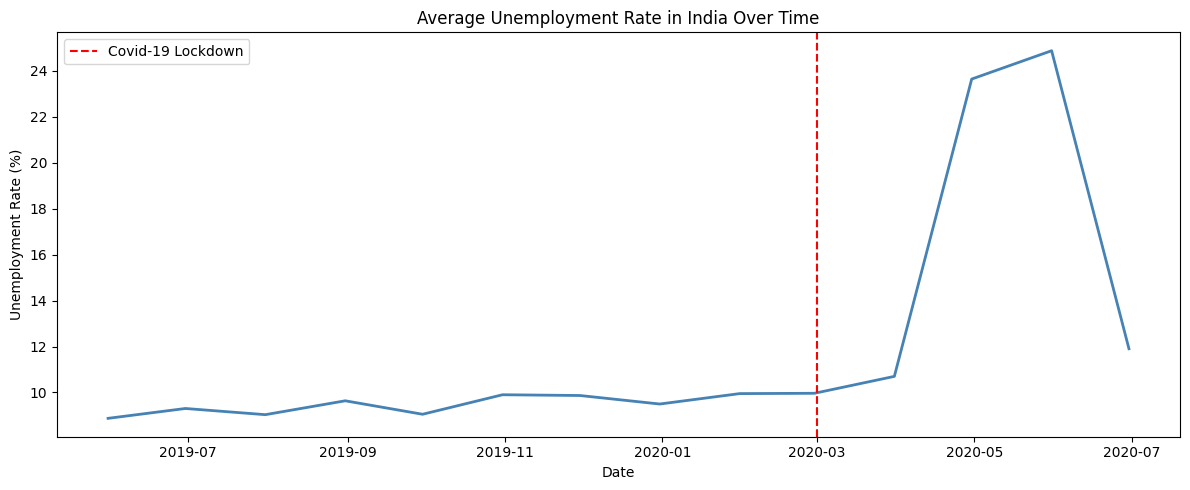

In [4]:
trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,5))
plt.plot(trend.index, trend.values, color='steelblue', linewidth=2)
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='Covid-19 Lockdown')
plt.title('Average Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

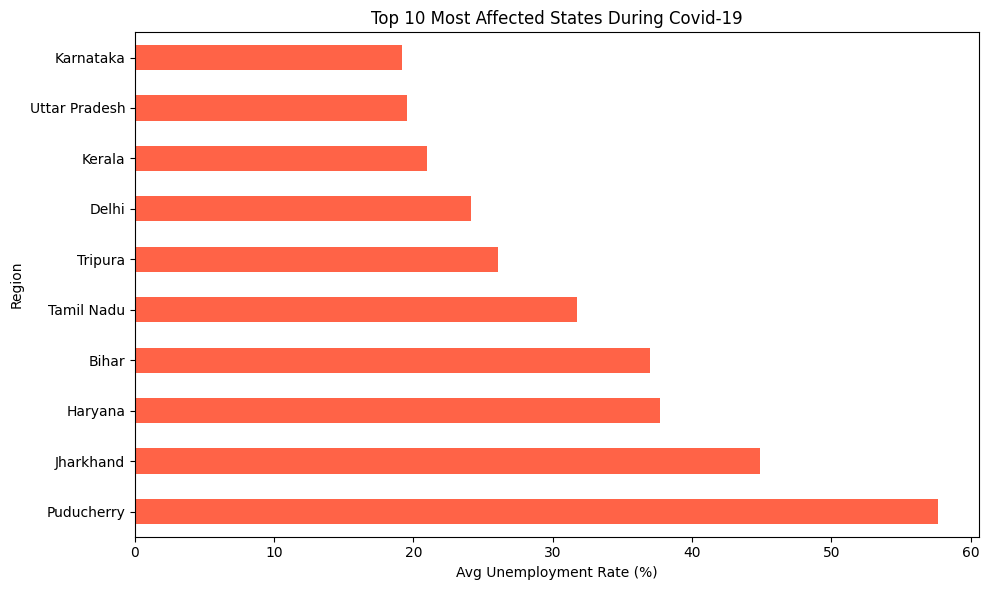

In [5]:
covid = df[df['Date'] >= '2020-04-01']
state_avg = covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
state_avg.plot(kind='barh', color='tomato')
plt.title('Top 10 Most Affected States During Covid-19')
plt.xlabel('Avg Unemployment Rate (%)')
plt.tight_layout()
plt.show()

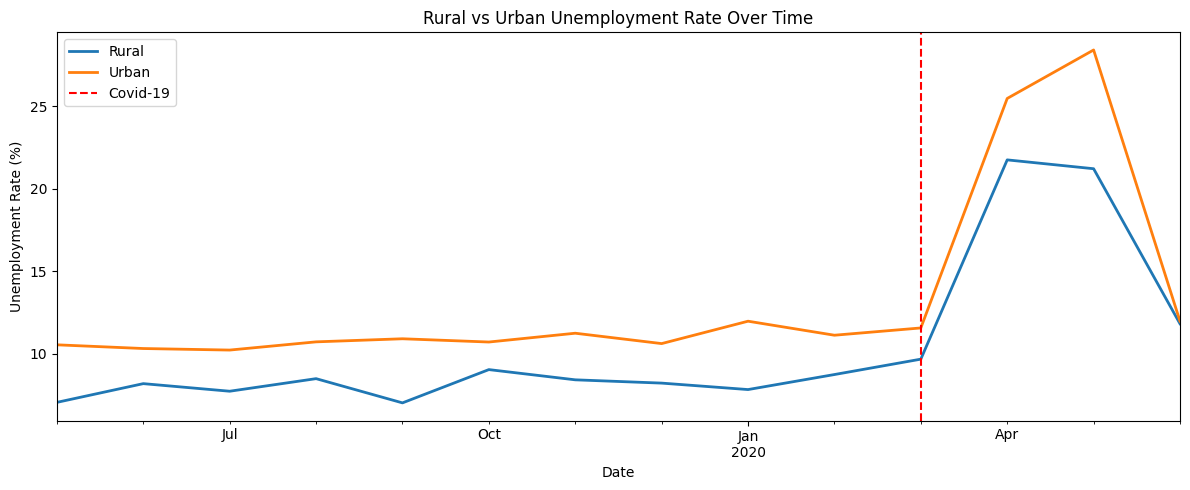

In [6]:
area = df.groupby(['Date','Area'])['Estimated Unemployment Rate (%)'].mean().unstack()

area.plot(figsize=(12,5), linewidth=2)
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='Covid-19')
plt.title('Rural vs Urban Unemployment Rate Over Time')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
pre = df[df['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
post = df[df['Date'] >= '2020-03-01']['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-Covid Average:  {pre:.2f}%")
print(f"Post-Covid Average: {post:.2f}%")
print(f"Increase:           {post - pre:.2f}%")

Pre-Covid Average:  9.51%
Post-Covid Average: 17.77%
Increase:           8.26%
